# 0. Connect Google Drive

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Import Libraries

In [30]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.backend import clear_session

# 2. Load Split Dataset

In [31]:
import sys

project_dir = "/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification"
sys.path.append(project_dir)

from utils import load_animals10_datasets

train_dataset, val_dataset, test_dataset, class_names = load_animals10_datasets()

Using Colab cache for faster access to the 'animals10' dataset.


### Check Data

In [32]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)

print(class_names)

(32, 128, 128, 3)
(32, 10)
['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


# 3. Define Model

In [33]:
from keras.backend import clear_session
clear_session()

In [34]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

num_classes = 10
input_shape= (128, 128, 3)

model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3,3), activation="relu"),
        layers.Conv2D(32, kernel_size=(3,3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Dropout(0.2),

        layers.Conv2D(64, kernel_size=(3,3), activation="relu"),
        layers.Conv2D(64, kernel_size=(3,3), activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),

        layers.Conv2D(64, kernel_size=(3,3), activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,384,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,488,362 (5.68 MB)

 Trainable params: 1,488,362 (5.68 MB)

 Non-trainable params: 0 (0.00 B)

# 4. Compile and Train Model

In [35]:
import time
from keras.optimizers import Adam

epochs = 30
my_opt = Adam(learning_rate=0.0001)

model.compile(
    loss="categorical_crossentropy",
    optimizer=my_opt,
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Track train time: starting timing
start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=[early_stop]
)
# Track train time: end timing
end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time / 60:.2f} minutes")

Epoch 1/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 43s 54ms/step - accuracy: 0.3224 - loss: 1.9154 - val_accuracy: 0.4343 - val_loss: 1.6685
Epoch 2/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 29s 44ms/step - accuracy: 0.4577 - loss: 1.5676 - val_accuracy: 0.5099 - val_loss: 1.4837
Epoch 3/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 30s 46ms/step - accuracy: 0.5186 - loss: 1.4084 - val_accuracy: 0.5336 - val_loss: 1.3883
Epoch 4/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 30s 45ms/step - accuracy: 0.5694 - loss: 1.2808 - val_accuracy: 0.5817 - val_loss: 1.2602
Epoch 5/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 42s 46ms/step - accuracy: 0.5943 - loss: 1.1979 - val_accuracy: 0.5940 - val_loss: 1.2209
Epoch 6/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 31s 47ms/step - accuracy: 0.6192 - loss: 1.1312 - val_accuracy: 0.5997 - val_loss: 1.1950
Epoch 7/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 30s 45ms/step - accuracy: 0.6387 - loss: 1.0738 - val_accuracy: 0.6238 - val_loss: 1.1545
Epoch 8/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 42s 46ms/step - accuracy: 0.6562 - loss: 1.0162 - 

# 5. Evaluate Model

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    true_labels = np.argmax(labels.numpy(), axis=1)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(true_labels)
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print(f"Test accuracy: {accuracy}")
print(f"Test precision: {precision}")
print(f"Test recall: {recall}")
print(f"Confusion Matrix: \n {cm}")

Test accuracy: 0.6363636363636364
Test precision: 0.6041078112283383
Test recall: 0.5988086365613646
Confusion Matrix: 
 [[305  43  14   5  15  33  17  19  15  21]
 [ 22 167  18   4   3   2  24  11   8   3]
 [  8  17  73   1   0   4   9  16  10   7]
 [  1   6   1 156   3   1   1   7  30   5]
 [ 19   7   2  10 219   5   9   9   7  23]
 [ 52   4   1   2   2  60   2   6  22  16]
 [ 24  40   9   0   5   2  82  20   2   2]
 [ 10  15   7   3   9   4  17 102   7   8]
 [ 15   4   6  21  12  10   3   9 389  13]
 [ 23   3   3   2   5  11   0  10  16 113]]


# 6.Plot Loss and Accuracy

In [37]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

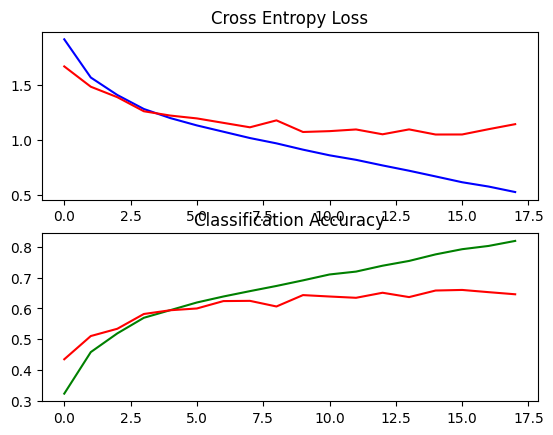

In [38]:
import matplotlib.pyplot as plt

plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history.history['loss'], color='blue', label='train')
plt.plot(history.history['val_loss'], color='red', label='validation')

plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(history.history['accuracy'], color='green', label='train')
plt.plot(history.history['val_accuracy'], color='red', label='validation')
plt.show()

# 6.2 Plot Comfusion Matrix

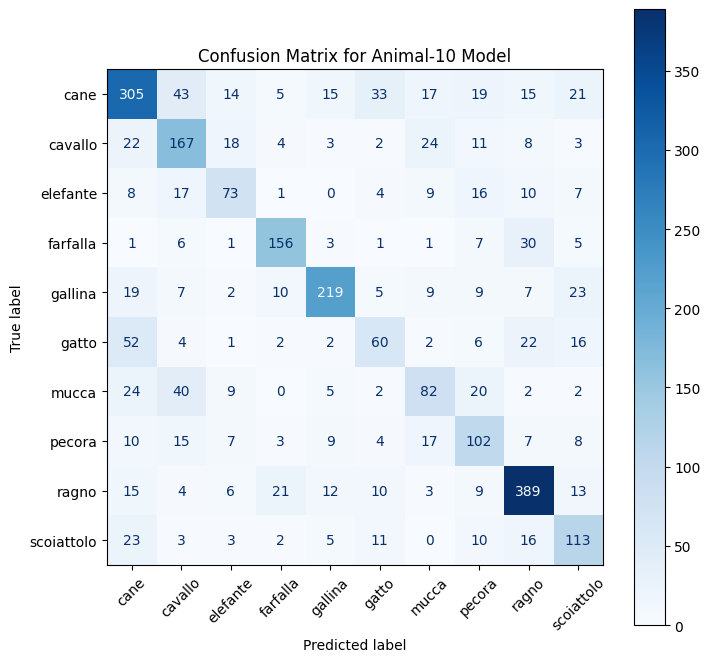

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap="Blues", values_format="d", ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix for Animal-10 Model")
plt.show()

# 7. Save Model

In [40]:
model.save("/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification/saved_models/model_2_deeper_cnn.keras")

print("Model Saved")

Model Saved


In [41]:
# how to import model when needed

'''
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification/saved_models/model_2_deeper_cnn.keras"
)
'''

'\nimport tensorflow as tf\n\nmodel = tf.keras.models.load_model(\n    "/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification/saved_models/model_2_deeper_cnn.keras"\n)\n'